# ALEX simulation basics

**ALEX** (alternating laser excitation) rapidly switches a green (donor) and a red (acceptor) laser on the **macro-time / diffusion timescale** — unlike PIE, which separates excitation by micro-time. `tttrlib`'s photon simulator models this with one excitation grid per laser and a per-laser brightness matrix `q_alex` on each species. A doubly-labelled molecule then emits **DD + DA** under the green laser and **AA** under the red laser.

This notebook builds a small, deterministic ALEX simulation (one immobile doubly-labelled molecule), shows the per-window laser alternation and the optional laser-switch **markers**, folds the macro-time to recover the excitation windows, and round-trips the stream through the ISS `SM` container and a lossless container.

In [1]:
%matplotlib inline
import numpy as np, tttrlib, tempfile, os

SM_CONTAINER, SM_RECORD, TY_F8 = 7, 11, 536870920

def sim_photon_arrays(ph, dt, macro_res):
    """Photon-only (macro_int, micro, routing) from SimEngine.photons() at a chosen resolution."""
    photon = ph["event_type"] == 0
    mw = ph["macro_window"][photon].astype(np.float64)
    arr = ph["arrival_time"][photon].astype(np.float64)
    macro = np.floor((mw * dt + arr) / macro_res).astype(np.uint64)
    order = np.argsort(macro, kind="stable")
    return (macro[order], ph["micro_time"][photon][order].astype(np.uint16),
            ph["channel"][photon][order].astype(np.int8))

def sim_photons_to_tttr(ph, dt, macro_res, container="SM", record_type=SM_RECORD, container_id=SM_CONTAINER):
    """Build a TTTR (photons only) from photons(). SM keeps macro+routing; PTU/Photon-HDF5 keep micro too."""
    macro, micro, routing = sim_photon_arrays(ph, dt, macro_res)
    d = tttrlib.TTTR(); d.append_events(macro, micro, routing, np.zeros(len(macro), np.int8))
    d.header.tttr_container_type = container_id; d.header.tttr_record_type = record_type
    d.header.set_tag("MeasDesc_GlobalResolution", macro_res, TY_F8)
    fn = tempfile.mktemp(suffix="." + container.lower().replace("-", ""))
    try:
        d.write(fn); return tttrlib.TTTR(fn, container)
    finally:
        if os.path.isfile(fn): os.unlink(fn)

def _contiguous_runs(mask):
    mask = np.asarray(mask, bool); n = len(mask)
    if n == 0 or not mask.any(): return []
    if mask.all(): return [(0, n - 1)]
    off = int(np.argmin(mask)); rolled = np.roll(mask, -off); runs = []; i = 0
    while i < n:
        if rolled[i]:
            j = i
            while j < n and rolled[j]: j += 1
            runs.append(((i + off) % n, (j - 1 + off) % n)); i = j
        else: i += 1
    return runs

def auto_alex_windows(phase, rc, donor_ch, acceptor_ch, period, n_bins=200, guard=0.06, occ=0.3):
    """Detect green/red ALEX windows from the folded phase using the donor detector.

    The donor detector is lit only under green excitation, so its phase histogram marks the green
    window; the red window is where the donor is dark but the acceptor is lit. Works with or
    without rise/fall gaps between the two laser windows.
    """
    phase = np.asarray(phase); rc = np.asarray(rc)
    edges = np.linspace(0, period, n_bins + 1)
    dc, _ = np.histogram(phase[np.isin(rc, donor_ch)], bins=edges)
    ac, _ = np.histogram(phase[np.isin(rc, acceptor_ch)], bins=edges)
    if dc.sum() == 0 or ac.sum() == 0:
        raise ValueError("need both donor and acceptor photons")
    rs = lambda c, r: (c[r[0]:r[1]+1].sum() if r[0] <= r[1] else c[r[0]:].sum() + c[:r[1]+1].sum())
    d_on = dc > occ * np.percentile(dc[dc > 0], 75)
    greens = _contiguous_runs(d_on)
    if not greens: raise ValueError("no green window")
    green = max(greens, key=lambda r: rs(dc, r))
    reds = _contiguous_runs((~d_on) & (ac > occ * np.percentile(ac[ac > 0], 75)))
    if not reds: raise ValueError("no red window - not ALEX?")
    red = max(reds, key=lambda r: rs(ac, r))
    def win(run):
        s, e = run
        lo = float(edges[s]); hi = float(edges[e+1]) if e+1 < len(edges) else float(period)
        m = guard * ((hi - lo) if hi > lo else (period - lo + hi))
        return (lo + m, hi - m)
    return {"green": win(green), "red": win(red), "phase_hist_edges": edges}


## Configure and run

`alex_period` is in macro-time units (`= dt`); with two excitation grids the engine assigns each macro-window to a laser (equal-duty). Here `alex_period = 0.04 = 4 windows = 2 per laser`. The green row `q_alex[0] = [180, 60]` emits into ch0 (DD) + ch1 (DA) with E=0.25; the red row `q_alex[1] = [0, 220]` emits only ch1 (AA). `alex_markers` writes an explicit laser-switch marker (event_type 2, routing = laser index).

In [2]:
dt = 0.01
cfg = {
    "settings": {"dt": dt, "n_ph_max": 200000, "n_channels": 2, "laser_period": 32.0,
                 "alex_period": 0.04, "alex_markers": True, "seed_diffusion": 1, "seed_emission": 2},
    "box": {"xy": 1.5, "z": 3.0},
    "species": [{"D": 0.0, "q_alex": [[180.0, 60.0], [0.0, 220.0]]}],
    "k_rad": [0], "k_nrad": [0], "background": [0.0, 0.0],
    "emitters": [{"x": 0.0, "y": 0.0, "z": 0.0, "species": 0}],
    "excitation": [
        {"type": "gaussian3d", "w0": 0.3, "z0": 2.0, "extent_xy": 1.5, "extent_z": 3.0, "spacing": 0.1},
        {"type": "gaussian3d", "w0": 0.3, "z0": 2.0, "extent_xy": 1.5, "extent_z": 3.0, "spacing": 0.1},
    ],
}
e = tttrlib.SimEngine.from_dict(cfg)
print("n_lasers =", e.n_lasers(), " alex_period =", e.alex_period())
e.run()
ph = e.photons()
photon = ph["event_type"] == 0
markers = ph["event_type"] == 2
print("photons:", photon.sum(), " laser-switch markers:", markers.sum())

n_lasers = 2  alex_period = 0.04
photons: 200002  laser-switch markers: 43479


## The laser alternates per macro-window

The active laser is a pure function of the window index. Donor-channel photons appear only in green windows; the acceptor channel is lit in both (DA in green, AA in red).

green window: DD(ch0)=78177  DA(ch1)=26059
red   window: ch0=0 (leakage)  AA(ch1)=95766
apparent E in green window = 0.250 (q_alex green 60/240 = 0.25)


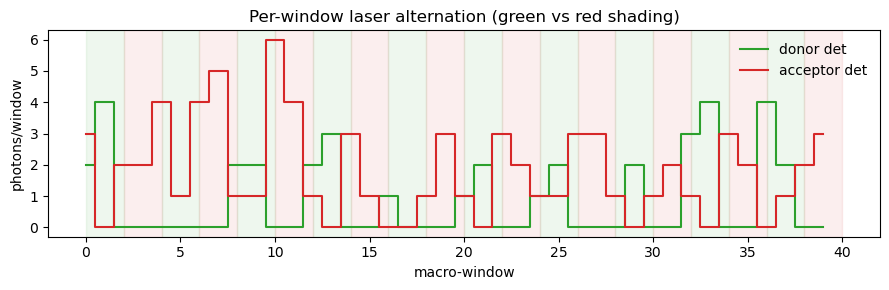

In [3]:
import matplotlib.pyplot as plt
wpl = int(round(cfg["settings"]["alex_period"] / dt / 2))  # windows per laser
laser = (ph["macro_window"] // wpl) % 2
g = photon & (laser == 0); r = photon & (laser == 1)
ch = ph["channel"]
print("green window: DD(ch0)=%d  DA(ch1)=%d" % ((ch[g]==0).sum(), (ch[g]==1).sum()))
print("red   window: ch0=%d (leakage)  AA(ch1)=%d" % ((ch[r]==0).sum(), (ch[r]==1).sum()))
print("apparent E in green window = %.3f (q_alex green 60/240 = 0.25)" % ((ch[g]==1).sum()/g.sum()))

# intensity of each detector across the first windows, shaded by laser
nwin = 40
fig, ax = plt.subplots(figsize=(9, 3))
for det, col, lab in [(0, "tab:green", "donor det"), (1, "tab:red", "acceptor det")]:
    m = photon & (ch == det) & (ph["macro_window"] < nwin)
    h, _ = np.histogram(ph["macro_window"][m], bins=np.arange(nwin+1))
    ax.step(np.arange(nwin), h, where="mid", color=col, label=lab)
for w0 in range(0, nwin, 2*wpl):
    ax.axvspan(w0, w0+wpl, color="tab:green", alpha=0.08)
    ax.axvspan(w0+wpl, w0+2*wpl, color="tab:red", alpha=0.08)
ax.set_xlabel("macro-window"); ax.set_ylabel("photons/window"); ax.legend(frameon=False)
ax.set_title("Per-window laser alternation (green vs red shading)")
plt.tight_layout(); plt.show()

## Recover the excitation window by folding the macro-time

Real ALEX encodes the alternation in the macro-time. We build a `TTTR` from the photon arrays (choosing the macro-time resolution so the period is an integer number of ticks), then `alex_to_microtime(period)` folds the macro-time into the ALEX phase — the donor detector marks the green window, the acceptor the red.

detected green (123, 1925)  red (2171, 3973)


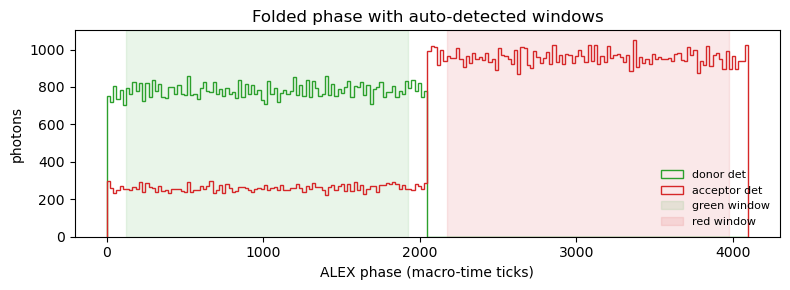

In [4]:
macro_res = dt / 1024
period_ticks = int(round(cfg["settings"]["alex_period"] / macro_res))
t = sim_photons_to_tttr(ph, dt, macro_res, container="SM")
t.alex_to_microtime(period_ticks, 0)
phase = np.asarray(t.micro_times); rc = np.asarray(t.routing_channels)
win = auto_alex_windows(phase, rc, [0], [1], period_ticks)
print("detected green", tuple(round(x) for x in win["green"]),
      " red", tuple(round(x) for x in win["red"]))

edges = win["phase_hist_edges"]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(phase[rc==0], bins=edges, histtype="step", color="tab:green", label="donor det")
ax.hist(phase[rc==1], bins=edges, histtype="step", color="tab:red", label="acceptor det")
ax.axvspan(*win["green"], color="tab:green", alpha=0.10, label="green window")
ax.axvspan(*win["red"], color="tab:red", alpha=0.10, label="red window")
ax.set_xlabel("ALEX phase (macro-time ticks)"); ax.set_ylabel("photons")
ax.set_title("Folded phase with auto-detected windows"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## Export: ISS `SM` (lossy) and a lossless container

The ISS `.sm` format stores macro-time + routing only (micro-time dropped) — exactly what a real ISS ALEX file carries. A lossless container (PicoQuant `PTU` or `Photon-HDF5`) additionally preserves the micro-time (FLIM) axis. Marker events are engine-level ground truth (`photons()['event_type']`); they are not stored as photon records.

In [5]:
ref_macro, ref_micro, ref_rc = sim_photon_arrays(ph, dt, macro_res)
sm = sim_photons_to_tttr(ph, dt, macro_res, container="SM")
print("SM   : macro match=%s  micro dropped=%s" % (
    np.array_equal(np.asarray(sm.macro_times), ref_macro),
    int(np.asarray(sm.micro_times).max()) == 0))
ptu = sim_photons_to_tttr(ph, dt, macro_res, container="PTU", record_type=4, container_id=0)
print("PTU  : macro match=%s  micro match=%s  routing match=%s" % (
    np.array_equal(np.asarray(ptu.macro_times), ref_macro),
    np.array_equal(np.asarray(ptu.micro_times), ref_micro),
    np.array_equal(np.asarray(ptu.routing_channels), ref_rc)))

SM   : macro match=True  micro dropped=True
PTU  : macro match=True  micro match=True  routing match=True
